# Datasets to SILVA

This notebook downloads a public tabular dataset, standardizes the columns, and
builds a sample graph.

For each feature column,

$$
\tilde X_{ij}=\frac{X_{ij}-\mu_j}{\max(\sigma_j,\varepsilon)}.
$$

The graph connects each sample to its $k$ nearest neighbors in standardized
feature space.

In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import torch
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})
from silva_networks import (
    SILVAGraphNetwork,
    SolverConfig,
    available_datasets,
    load_tabular_dataset,
    resolve_device,
    tabular_to_silva_graph,
)

available_datasets()[:8]

['abalone',
 'airfoil_self_noise',
 'banknote_authentication',
 'forest_fires',
 'glass',
 'heart_cleveland',
 'iris',
 'seeds']

The loader returns a small `TabularDataset` object. The adapter turns the table
into the package graph contract:

$$
(X,y)\longmapsto (x,E,b,y).
$$

Here $x$ is the standardized feature matrix, $E$ is the kNN edge set, and
`batch` is omitted because all rows form one graph.

In [3]:
device = resolve_device("auto")
dataset = load_tabular_dataset("iris", root="data", download=True, normalize=True)
graph = tabular_to_silva_graph(dataset, k=8, normalize=True, device=device)
x = graph.x
y = graph.y
edge_index = graph.edge_index
dataset.name, x.shape, y.shape, dataset.target_names

('iris',
 torch.Size([150, 4]),
 torch.Size([150]),
 ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'])

The edge tensor has shape $(2,E)$. The first row contains source indices and
the second row contains destination indices:

$$
\texttt{edge\_index}
=
\begin{bmatrix}
j_1&\cdots&j_E\\
i_1&\cdots&i_E
\end{bmatrix}.
$$

In [4]:
edge_index.shape

torch.Size([2, 1200])

The classifier treats each row as a node. The local branch is dynamic top-k
interaction and the global branch is mean-field context:

$$
z^\star
=
f_\theta(z^\star,x,E),
\qquad
\hat y_i=R_\phi(z_i^\star).
$$

In [5]:
model = SILVAGraphNetwork(
    in_dim=x.shape[1],
    hidden_dims=[16, 16],
    out_dim=len(dataset.target_names),
    task="node",
    local="topk",
    local_kwargs={"k": 8},
    global_term="mean",
    config=SolverConfig(solver="anderson", max_iter=8, alpha=0.5, history=4),
    head_hidden_dims=(16,),
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-2)
losses = []
for step in range(6):
    logits = model(x, edge_index=edge_index)
    loss = torch.nn.functional.cross_entropy(logits, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    losses.append(float(loss.detach().cpu()))
    print(step, float(loss.detach().cpu()))

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


0 1.1776119470596313
1 1.0259661674499512
2 0.9815155267715454
3 0.9326263666152954
4 0.8428500294685364
5 0.7616113424301147


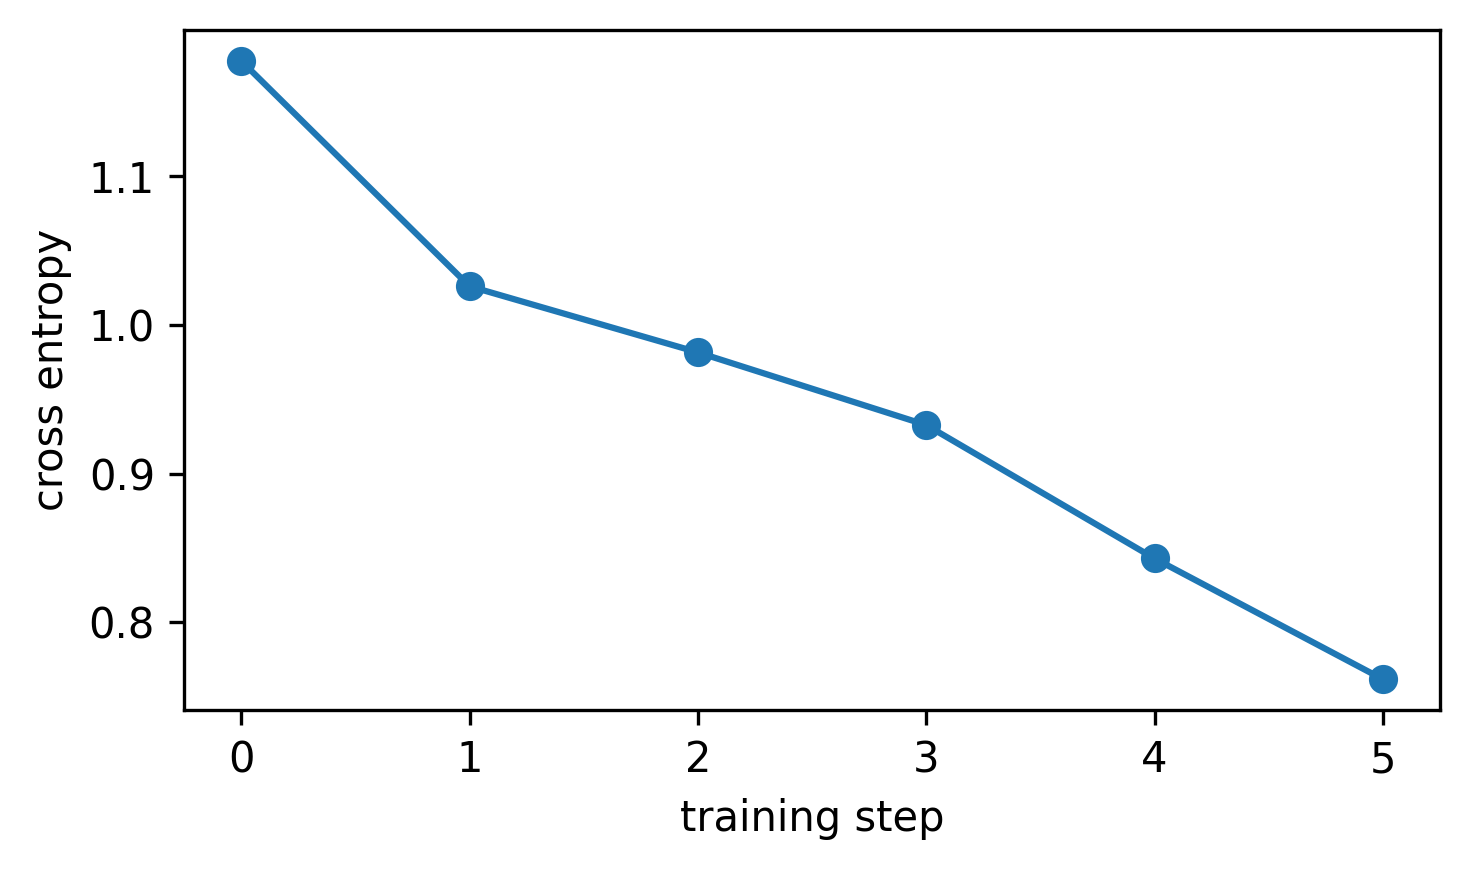

In [6]:
plt.figure(figsize=(5, 3))
plt.plot(losses, marker="o")
plt.xlabel("training step")
plt.ylabel("cross entropy")
plt.tight_layout()

In [7]:
accuracy = float((logits.argmax(dim=1) == y).float().mean().detach().cpu())
accuracy

0.8600000143051147

## Citation and Sources

If this notebook or package is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.0.0. MIT License.
https://github.com/jseluis/silva-networks
```

When the work is connected to the SILVA Networks paper, cite the paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background references used in the tutorial suite include:

- Deep Equilibrium Models, Bai, Kolter, and Koltun, NeurIPS 2019:
  https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models, Bai, Koltun, and Kolter, NeurIPS 2020:
  https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization, Bai, Koltun, and
  Kolter, ICML 2021: https://arxiv.org/abs/2106.14342
- Graph Attention Networks, Velickovic et al., ICLR 2018:
  https://arxiv.org/abs/1710.10903
- Attention Is All You Need, Vaswani et al., 2017:
  https://arxiv.org/abs/1706.03762